## Experiment No: 5
## Experiment Title: Linear Regression — Boston Housing Price Prediction

**Name:** Himanshu Jadhav  
**Roll Number:** SE-33

### 📌 Problem Statement

- Load the Boston Housing dataset.
- Train a Linear Regression model to predict house prices.
- Evaluate the model using MAE, MSE, RMSE, and R² Score.

> **Dataset:** https://www.kaggle.com/datasets/altavish/boston-housing-dataset


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [2]:
# Load The Dataset

df = pd.read_csv("HousingData.csv")
print("Shape: ", df.shape)
print(df.head())

Shape:  (506, 14)
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  


In [3]:
# Handling the Missing Values

df.fillna(df.median(), inplace=True)
print("Missing Values: ", df.isnull().values.sum())

Missing Values:  0


In [4]:
# Defining The Features & Targets

x = df.drop(columns=['MEDV'])
y = df['MEDV']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f"Train: {x_train.shape}, Test: {x_test.shape}")



Train: (404, 13), Test: (102, 13)


In [5]:
# Model Training

model = LinearRegression()
model.fit(x_train, y_train)
print("Model Trained Successfully...")

Model Trained Successfully...


In [6]:
# Predict and Evaluate

y_pred = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred) # Mean Absolute Error
mse = mean_squared_error(y_test, y_pred)  # Mean Squared Error
rmse = np.sqrt(mse)                       # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)             # Coefficient of Determination

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}") 

MAE  : 3.1487
MSE  : 24.9994
RMSE : 4.9999
R²   : 0.6591


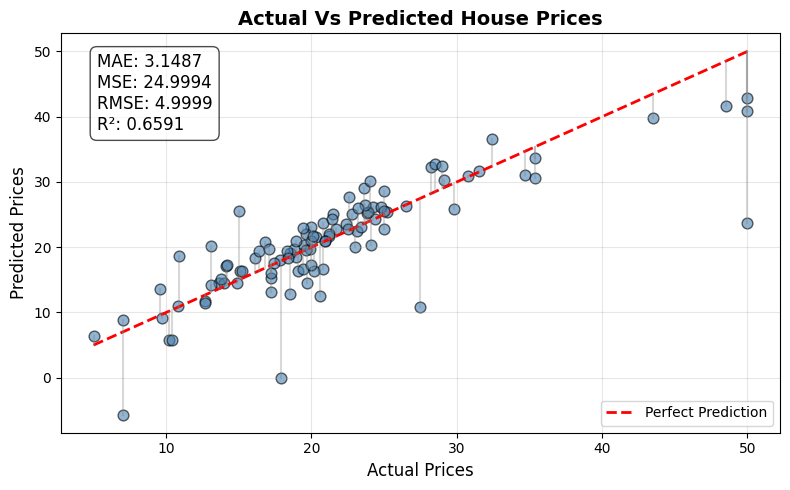

In [7]:
# Plot of Actual Vs. Predicted 

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, color="steelblue", alpha=0.6, edgecolor="k",s=60)

min_val, max_val = y_test.min(), y_test.max()
plt.plot([min_val,max_val], [min_val, max_val], "r--", lw=2, label="Perfect Prediction")

for actual, pred in zip(y_test, y_pred):
    plt.plot([actual, actual], [actual, pred], color="grey", alpha=0.3)

plt.title("Actual Vs Predicted House Prices", fontsize=14, fontweight="bold")
plt.xlabel("Actual Prices",fontsize=12)
plt.ylabel("Predicted Prices",fontsize=12)

plt.legend()
plt.grid(alpha=0.3)
metrics_text = f"MAE: {mae:.4f}\nMSE: {mse:.4f}\nRMSE: {rmse:.4f}\nR²: {r2:.4f}"
plt.text(0.05, 0.95, metrics_text, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.7))


plt.tight_layout()
plt.show()